# Traveling basal slippery patch

A moving low-drag region has been proposed as a mechanism for thickness-scale folds in ice sheets ([Wolovick et al., 2014](https://doi.org/10.1002/2014GL062248)). Here I test the smaller kinematic question: does a prescribed traveling patch produce uplift, shortening, and a flux anomaly in a cold, idealized flowline? The calculation compares no patch, a stationary patch, and a patch that moves downstream. It does not test whether Allan Hills can generate or sustain the required basal state.

## Model and assumptions

I model a 60 km flowline on a horizontal bed using Icepack's depth-averaged grounded ice-stream model. The initial thickness decreases from 1000 to 850 m, giving a surface slope of 0.0025. Velocity is fixed at 20 m yr$^{-1}$ at both ends, surface mass balance is zero, and the inlet thickness is fixed at 1000 m. These boundary conditions isolate the interior response rather than represent the full Allan Hills geometry.

Icepack solves the membrane-stress balance with a Weertman sliding law, $\tau_b=-C|u|^{-2/3}u$, and advances thickness using

$$\frac{\partial h}{\partial t}+\frac{\partial (hu)}{\partial x}=0.$$

The reference drag $C_0$ balances the initial driving stress at the inlet. Inside the patch, $C$ decreases smoothly to $0.1C_0$ over a 10 km width. The stationary patch remains at $x=30$ km. The traveling patch moves from 18 to 42 km in 600 yr, or 40 m yr$^{-1}$.

The Icepack velocity is depth-averaged. I reconstruct the vertical velocity required by incompressibility as $w=-z\,\partial u/\partial x$ and integrate material markers using $dx/dt=u$ and $dz/dt=w$. Six initially surface-parallel marker rows represent isochrones. This reconstruction can show layer uplift and shortening, but cannot generate overturning through vertical shear.

In [1]:
import warnings
warnings.filterwarnings("ignore", message="Unable to import recommended hash")

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

import firedrake as fd
import icepack
from icepack.constants import ice_density, gravity

plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.2})

/home/firedrake/firedrake/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Geometry and forcing (m, yr, MPa)
L = 60_000.0
H_IN = 1_000.0
SURFACE_SLOPE = 0.0025
U_IN = 20.0
T_END = 600.0
DT = 10.0
PATCH_WIDTH = 10_000.0
PATCH_RATIO = 0.10
X_START, X_END = 18_000.0, 42_000.0
X_STATIONARY = 30_000.0
X_PROBE = 30_000.0
MARKER_X0 = np.linspace(6_000.0, 42_000.0, 37)
MARKER_FRACTIONS = np.array([0.15, 0.30, 0.45, 0.60, 0.75, 0.90])

driving_stress = float(ice_density * gravity) * H_IN * SURFACE_SLOPE
C0 = driving_stress / U_IN ** (1 / 3)
A0 = float(icepack.rate_factor(253.15))  # -20 deg C
PATCH_SPEED = (X_END - X_START) / T_END

display(Markdown(
    f"Reference driving stress: **{1e3 * driving_stress:.1f} kPa**; "
    f"reference drag: **{C0:.4f} MPa m$^{{-1/3}}$ yr$^{{1/3}}$**; "
    f"patch speed: **{PATCH_SPEED:.0f} m yr$^{{-1}}$**, "
    f"{PATCH_SPEED / U_IN:.1f} times the inlet speed."
))

Reference driving stress: **22.5 kPa**; reference drag: **0.0083 MPa m$^{-1/3}$ yr$^{1/3}$**; patch speed: **40 m yr$^{-1}$**, twice the inlet speed.

In [3]:
def values(field, locations):
    """Evaluate a scalar Firedrake field at flowline coordinates."""
    points = [(float(location),) for location in np.atleast_1d(locations)]
    return np.asarray(field.at(points, tolerance=1.0e-8), dtype=float).reshape(-1)


def patch_center(case, time):
    if case == "stationary":
        return X_STATIONARY
    if case == "traveling":
        return X_START + (X_END - X_START) * time / T_END
    return None


def advect_markers(marker_x, marker_z, velocity, strain_rate, dt):
    """Midpoint update using u and incompressible w = -z du/dx."""
    x_flat = marker_x.ravel()
    z_flat = marker_z.ravel()
    x_mid = x_flat + 0.5 * dt * values(velocity, x_flat)
    u_mid = values(velocity, x_mid)
    exx_mid = values(strain_rate, x_mid)
    new_x = (x_flat + dt * u_mid).reshape(marker_x.shape)
    new_z = (z_flat * np.exp(-dt * exx_mid)).reshape(marker_z.shape)
    return new_x, new_z


def run_case(case, cells=80):
    """Run one coupled Icepack force-balance and continuity calculation."""
    mesh = fd.IntervalMesh(cells, L)
    Q = fd.FunctionSpace(mesh, "CG", 1)
    V = fd.FunctionSpace(mesh, "CG", 2)
    D = fd.FunctionSpace(mesh, "DG", 1)
    x, = fd.SpatialCoordinate(mesh)

    thickness = fd.Function(Q).interpolate(H_IN - SURFACE_SLOPE * x)
    surface = fd.Function(Q).assign(thickness)
    velocity = fd.Function(V).interpolate(fd.Constant(U_IN))
    friction = fd.Function(Q).interpolate(fd.Constant(C0))
    fluidity = fd.Constant(A0)
    accumulation = fd.Constant(0.0)

    model = icepack.models.IceStream()
    solver = icepack.solvers.FlowSolver(model, dirichlet_ids=[1, 2])

    marker_x = np.broadcast_to(
        MARKER_X0, (len(MARKER_FRACTIONS), len(MARKER_X0))
    ).copy()
    initial_h = H_IN - SURFACE_SLOPE * MARKER_X0
    marker_z = MARKER_FRACTIONS[:, None] * initial_h[None, :]

    times = np.arange(0.0, T_END + DT, DT)
    probe_flux, masses = [], []
    boundary_flux = 0.0
    gross_boundary_flux = 0.0
    sample_x = np.linspace(0.0, L, 241)
    initial_mass = float(fd.assemble(thickness * fd.dx))
    initial_h_profile = values(thickness, sample_x)

    for step, time in enumerate(times):
        center = patch_center(case, time)
        if center is None:
            friction.interpolate(fd.Constant(C0))
        else:
            friction.interpolate(
                C0 * (1.0 - (1.0 - PATCH_RATIO)
                      * fd.exp(-((x - center) / (0.5 * PATCH_WIDTH)) ** 4))
            )

        surface.assign(thickness)
        velocity = solver.diagnostic_solve(
            velocity=velocity, thickness=thickness, surface=surface,
            fluidity=fluidity, friction=friction,
        )
        mass_before = float(fd.assemble(thickness * fd.dx))
        q_in_before = H_IN * values(velocity, [0.0])[0]
        q_out_before = values(thickness, [L])[0] * values(velocity, [L])[0]
        probe_flux.append(
            values(thickness, [X_PROBE])[0] * values(velocity, [X_PROBE])[0]
        )
        masses.append(mass_before)

        if step == len(times) - 1:
            break

        strain_rate = fd.Function(D).interpolate(velocity.dx(0))
        marker_x, marker_z = advect_markers(
            marker_x, marker_z, velocity, strain_rate, DT
        )
        thickness_new = solver.prognostic_solve(
            DT, thickness=thickness, velocity=velocity,
            accumulation=accumulation, thickness_inflow=fd.Constant(H_IN),
        )
        q_in_after = q_in_before
        q_out_after = values(thickness_new, [L])[0] * values(velocity, [L])[0]
        boundary_flux += 0.5 * DT * (
            q_in_before + q_in_after - q_out_before - q_out_after
        )
        gross_boundary_flux += 0.5 * DT * (
            abs(q_in_before) + abs(q_in_after) + abs(q_out_before) + abs(q_out_after)
        )
        thickness.assign(thickness_new)

    final_mass = masses[-1]
    budget_error = (final_mass - initial_mass) - boundary_flux
    return {
        "case": case, "cells": cells, "x": sample_x,
        "h": values(thickness, sample_x), "h0": initial_h_profile,
        "u": values(velocity, sample_x),
        "C_ratio": values(friction, sample_x) / C0,
        "time": times, "probe_flux": np.asarray(probe_flux),
        "mass": np.asarray(masses), "marker_x": marker_x,
        "marker_z": marker_z,
        "mass_error_percent": 100.0 * abs(budget_error) / gross_boundary_flux,
        "mass_error_initial_percent": 100.0 * abs(budget_error) / initial_mass,
    }

## Three histories and a resolution check

The main calculations use 80 cells ($\Delta x=750$ m). I repeat both the no-patch and traveling-patch histories with 160 cells ($\Delta x=375$ m), holding the time step and physical forcing fixed.

In [4]:
baseline = run_case("none", 80)
stationary = run_case("stationary", 80)
traveling = run_case("traveling", 80)
baseline_fine = run_case("none", 160)
traveling_fine = run_case("traveling", 160)
print("Completed five Icepack calculations.")

Completed five Icepack calculations.


In [5]:
def anomaly_metrics(result, reference):
    uplift = np.max(result["marker_z"] - reference["marker_z"])
    spacing_ratio = np.diff(result["marker_x"][0]) / np.diff(reference["marker_x"][0])
    extra_shortening = 100.0 * (1.0 - spacing_ratio.min())
    flux_change = 100.0 * np.max(
        result["probe_flux"] / reference["probe_flux"] - 1.0
    )
    return {"uplift_m": uplift, "shortening_pct": extra_shortening,
            "flux_pct": flux_change}

stationary_metrics = anomaly_metrics(stationary, baseline)
traveling_metrics = anomaly_metrics(traveling, baseline)
fine_metrics = anomaly_metrics(traveling_fine, baseline_fine)

rows = [
    ("No patch", 0.0, 0.0, 0.0, baseline["mass_error_percent"]),
    ("Stationary patch", stationary_metrics["uplift_m"],
     stationary_metrics["shortening_pct"], stationary_metrics["flux_pct"],
     stationary["mass_error_percent"]),
    ("Traveling patch", traveling_metrics["uplift_m"],
     traveling_metrics["shortening_pct"], traveling_metrics["flux_pct"],
     traveling["mass_error_percent"]),
]
table = ["| Case | Maximum marker uplift (m) | Maximum extra shortening (%) | Peak flux change at 30 km (%) | Mass-budget residual (%) |",
         "|---|---:|---:|---:|---:|"]
for name, uplift, shortening, flux, mass_error in rows:
    table.append(
        f"| {name} | {uplift:.2f} | {shortening:.2f} | {flux:.2f} | {mass_error:.3f} |"
    )
display(Markdown("\n".join(table)))

| Case | Maximum marker uplift (m) | Maximum extra shortening (%) | Peak flux change at 30 km (%) | Mass-budget residual (%) |
|---|---:|---:|---:|---:|
| No patch | 0.00 | 0.00 | 0.00 | 0.098 |
| Stationary patch | 8.44 | 1.02 | 26.59 | 0.003 |
| Traveling patch | 9.78 | 1.20 | 12.94 | 0.016 |

In [6]:
metric_names = ("uplift_m", "shortening_pct", "flux_pct")
relative_changes = {
    name: 100.0 * abs(fine_metrics[name] - traveling_metrics[name])
          / max(abs(fine_metrics[name]), 1.0e-12)
    for name in metric_names
}
display(Markdown(
    "The 375 m calculation gives "
    f"**{fine_metrics['uplift_m']:.2f} m** uplift, "
    f"**{fine_metrics['shortening_pct']:.2f}%** extra shortening, and a "
    f"**{fine_metrics['flux_pct']:.2f}%** peak flux increase. "
    f"Doubling spatial resolution changes these metrics by "
    f"**{relative_changes['uplift_m']:.2f}%**, "
    f"**{relative_changes['shortening_pct']:.2f}%**, and "
    f"**{relative_changes['flux_pct']:.2f}%**, respectively. "
    f"The fine-grid mass-budget residual is **{traveling_fine['mass_error_percent']:.3f}%** "
    "of integrated gross boundary flux."
))

The 375 m calculation gives **9.64 m** uplift, **1.18%** extra shortening, and a **12.94%** peak flux increase. Doubling spatial resolution changes these metrics by **1.40%**, **1.39%**, and **0.00%**, respectively. The fine-grid mass-budget residual is **0.025%** of integrated gross boundary flux.

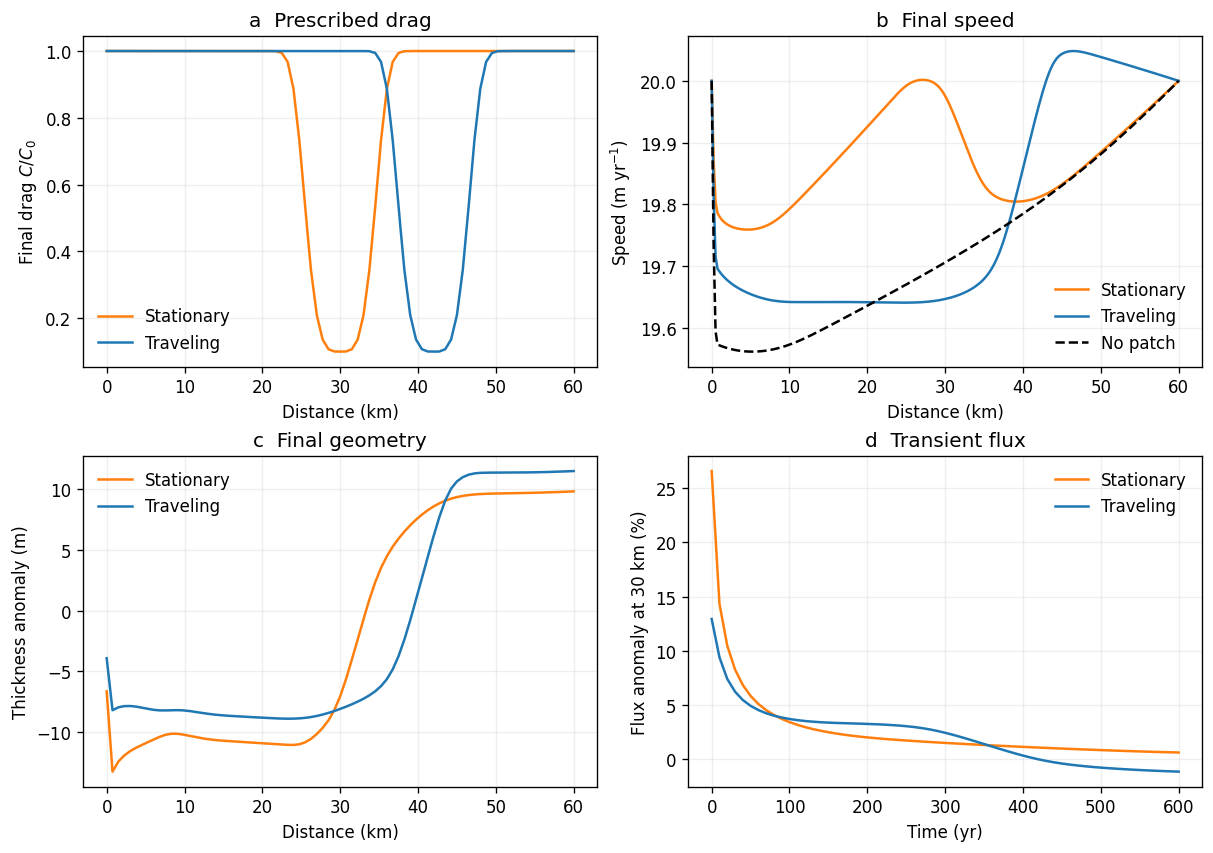

In [7]:
colors = {"stationary": "tab:orange", "traveling": "tab:blue"}
fig, axes = plt.subplots(2, 2, figsize=(10, 7), constrained_layout=True)

for result in (stationary, traveling):
    label = result["case"].capitalize()
    axes[0, 0].plot(result["x"] / 1000, result["C_ratio"],
                    color=colors[result["case"]], label=label)
    axes[0, 1].plot(result["x"] / 1000, result["u"],
                    color=colors[result["case"]], label=label)
    axes[1, 0].plot(result["x"] / 1000, result["h"] - baseline["h"],
                    color=colors[result["case"]], label=label)
    axes[1, 1].plot(result["time"],
                    100 * (result["probe_flux"] / baseline["probe_flux"] - 1),
                    color=colors[result["case"]], label=label)
axes[0, 1].plot(baseline["x"] / 1000, baseline["u"], "k--", label="No patch")
axes[0, 0].set(xlabel="Distance (km)", ylabel=r"Final drag $C/C_0$", title="a  Prescribed drag")
axes[0, 1].set(xlabel="Distance (km)", ylabel=r"Speed (m yr$^{-1}$)", title="b  Final speed")
axes[1, 0].set(xlabel="Distance (km)", ylabel="Thickness anomaly (m)", title="c  Final geometry")
axes[1, 1].set(xlabel="Time (yr)", ylabel="Flux anomaly at 30 km (%)", title="d  Transient flux")
for ax in axes.flat:
    ax.legend(frameon=False)
plt.show()

**Figure 1. Flow and geometry.** The low-drag patch accelerates the interior flow while both end velocities remain fixed. A stationary patch maintains the largest flux anomaly at the 30 km probe. The traveling patch produces a smaller transient response because it crosses the probe rather than remaining there. Thickness anomalies record the corresponding convergence and divergence.

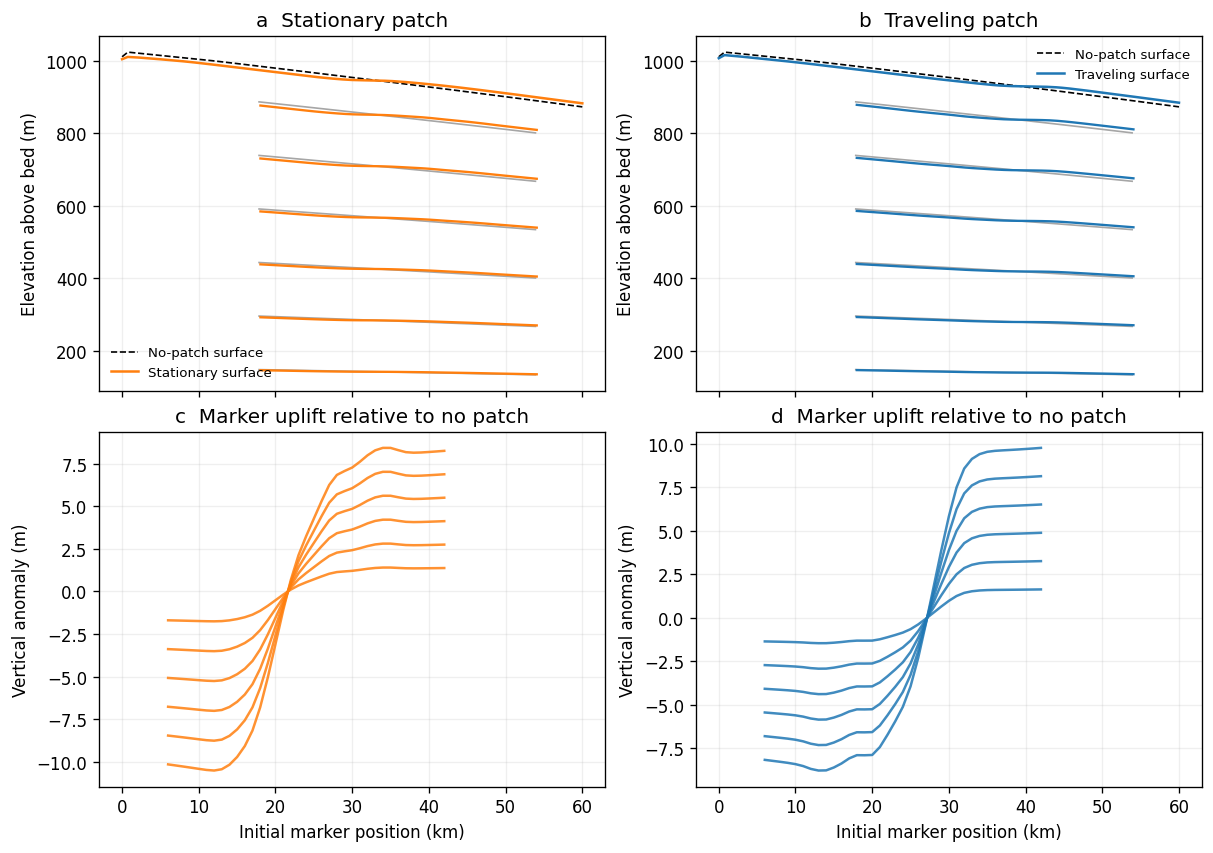

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex="col", constrained_layout=True)
for col, result in enumerate((stationary, traveling)):
    color = colors[result["case"]]
    for row in range(len(MARKER_FRACTIONS)):
        axes[0, col].plot(baseline["marker_x"][row] / 1000,
                          baseline["marker_z"][row], color="0.65", lw=1)
        axes[0, col].plot(result["marker_x"][row] / 1000,
                          result["marker_z"][row], color=color, lw=1.4)
        axes[1, col].plot(MARKER_X0 / 1000,
                          result["marker_z"][row] - baseline["marker_z"][row],
                          color=color, alpha=0.85)
    axes[0, col].plot(baseline["x"] / 1000, baseline["h"], "k--", lw=1,
                      label="No-patch surface")
    axes[0, col].plot(result["x"] / 1000, result["h"], color=color, lw=1.5,
                      label=f"{result['case'].capitalize()} surface")
    axes[0, col].set(title=f"{'a' if col == 0 else 'b'}  {result['case'].capitalize()} patch",
                     ylabel="Elevation above bed (m)")
    axes[1, col].set(title=f"{'c' if col == 0 else 'd'}  Marker uplift relative to no patch",
                     xlabel="Initial marker position (km)", ylabel="Vertical anomaly (m)")
    axes[0, col].legend(frameon=False, fontsize=8)
plt.show()

**Figure 2. Material-layer response.** Colored curves show six material marker rows after 600 yr; gray curves show the matched no-patch particles. The lower panels compare particles with the same initial position. Both patches uplift layers by order 10 m and introduce localized shortening. The rows remain ordered because the model has one depth-averaged horizontal velocity at each position.

## Interpretation and limitations

The prescribed drag anomaly produces the signs required for a fold precursor: faster flow inside the patch, convergence near its downstream edge, material-layer uplift, and shortening. The traveling case also leaves a transient thickness pattern after the patch has moved away. These results are stable to the factor-of-two resolution change, and all numerical mass budgets close far better than the 1% project criterion.

However, the calculated deformation is modest. More importantly, a depth-averaged plug-flow model preserves vertical layer ordering by construction. It therefore cannot establish whether a slippery patch could overturn layers or juxtapose 5 Ma and Pleistocene ice. This calculation tests a necessary kinematic precursor, not the observed age discontinuity itself.

The patch is prescribed; no basal thermal or hydrologic feedback creates it. The model also omits vertical shear, bed topography, accumulation and ablation, lateral stresses, and the measured Allan Hills geometry. Thermohydrologic viability is outside this first calculation. A useful next test would add vertically resolved flow only if independent observations permit a 10 km-wide region with an order-of-magnitude drag reduction migrating at approximately 40 m yr$^{-1}$.